In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")


fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/raw/02_nav_history.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

transaction = pd.read_csv("../data/raw/08_investor_transactions.csv")

holding = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

datasets = {
    "Fund": fund,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transaction": transaction,
    "Holding": holding,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.shape)


Fund
(40, 15)

NAV
(46000, 3)

AUM
(90, 5)

SIP
(48, 6)

Category
(144, 3)

Folio
(21, 6)

Performance
(40, 19)

Transaction
(32778, 13)

Holding
(322, 8)

Benchmark
(8050, 3)


## Finding 1: Daily NAV Trend

**Observation:**

- The NAV of mutual fund schemes shows an overall upward trend over the analysis period.
- Temporary fluctuations indicate normal market volatility.
- Most schemes demonstrate positive long-term growth, making them suitable for long-term investment.

In [16]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend"
)
fig.write_image("../reports/charts/01_nav_trend.png")
fig.show()

## Finding 2: Assets Under Management (AUM)

**Observation:**

- A few fund houses manage significantly larger assets than others.
- Higher AUM reflects stronger investor trust and market presence.
- The distribution indicates that the mutual fund industry is dominated by leading fund houses.

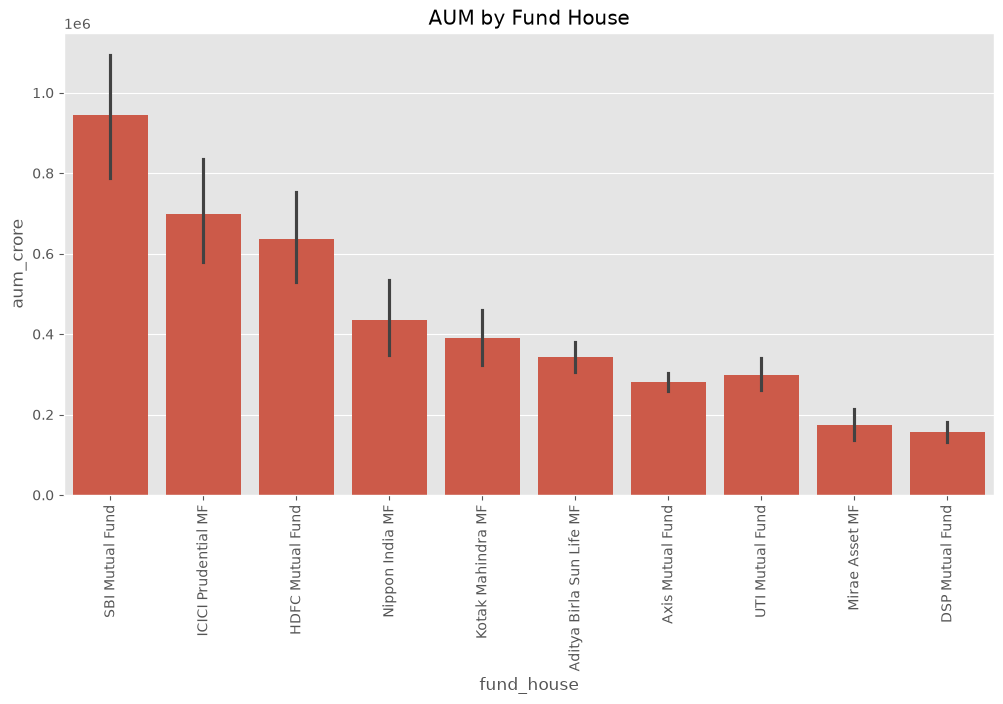

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")
plt.savefig("../reports/charts/02_aum_chart.png", dpi=300)
plt.show()

## Finding 3: Monthly SIP Inflows

**Observation:**

- SIP inflows show a consistent increasing trend across the years.
- The steady growth reflects increasing awareness of systematic investing.
- The highest monthly inflow indicates strong investor confidence during that period.

In [18]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Trend"
)
fig.write_image("../reports/charts/03_sip_trend.png")

fig.show()

## Finding 4: Category-wise Investment Flow

**Observation:**

- Equity fund categories received higher inflows than debt categories in most months.
- Investment activity varies across different fund categories and time periods.
- The heatmap highlights periods of strong investor interest in specific categories.

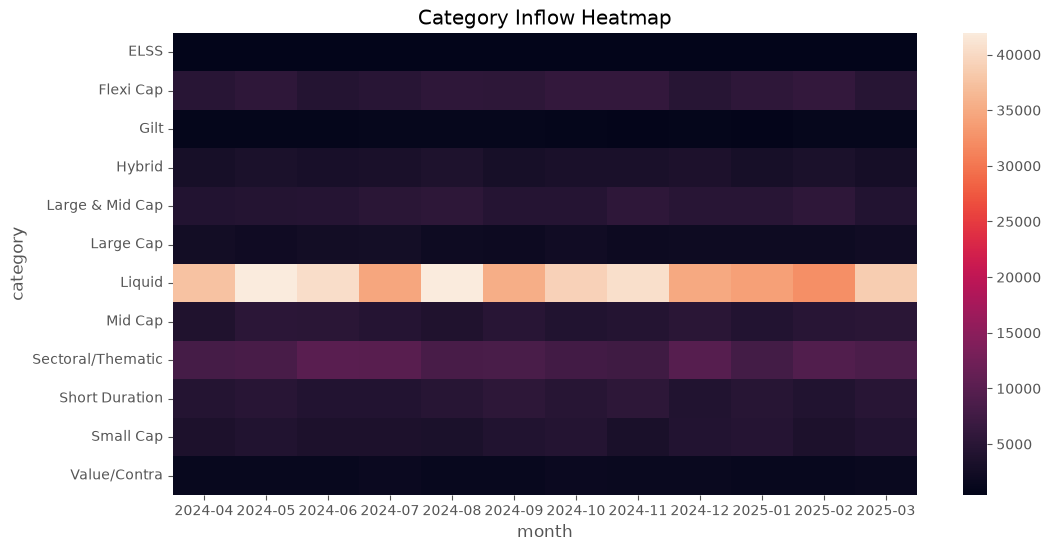

In [19]:
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

plt.figure(figsize=(12,6))

sns.heatmap(pivot)

plt.title("Category Inflow Heatmap")
plt.savefig("../reports/charts/04_category_heatmap.png", dpi=300)
plt.show()

## Finding 5: Investor Age Distribution

**Observation:**

- Most investors belong to the middle-age group.
- Younger and older age groups contribute comparatively fewer investments.
- This indicates that working professionals form the largest investor segment.

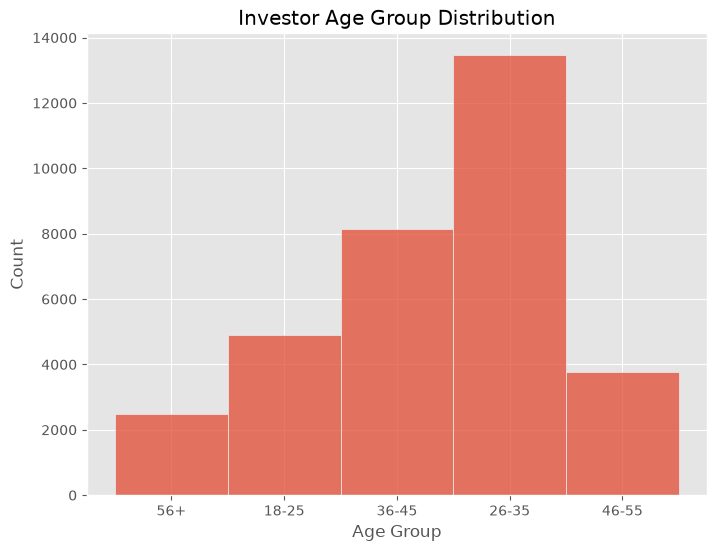

In [20]:
plt.figure(figsize=(8,6))

sns.histplot(
    transaction["age_group"],
    bins=10
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.savefig("../reports/charts/05_age_distribution.png", dpi=300)
plt.show()


## Finding 6: Gender-wise Participation

**Observation:**

- The chart illustrates the proportion of investments made by different genders.
- One gender contributes a larger share of total investments.
- Understanding demographic participation helps identify investor behavior patterns.

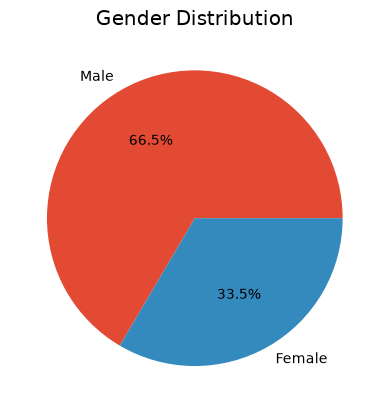

In [21]:
transaction["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.savefig("../reports/charts/06_gender_distribution.png", dpi=300)
plt.show()

## Finding 7: State-wise Investor Distribution

**Observation:**

- A small number of states contribute the highest number of investor transactions.
- Metropolitan and economically developed states show greater investment activity.
- Geographic distribution highlights regional differences in mutual fund participation.

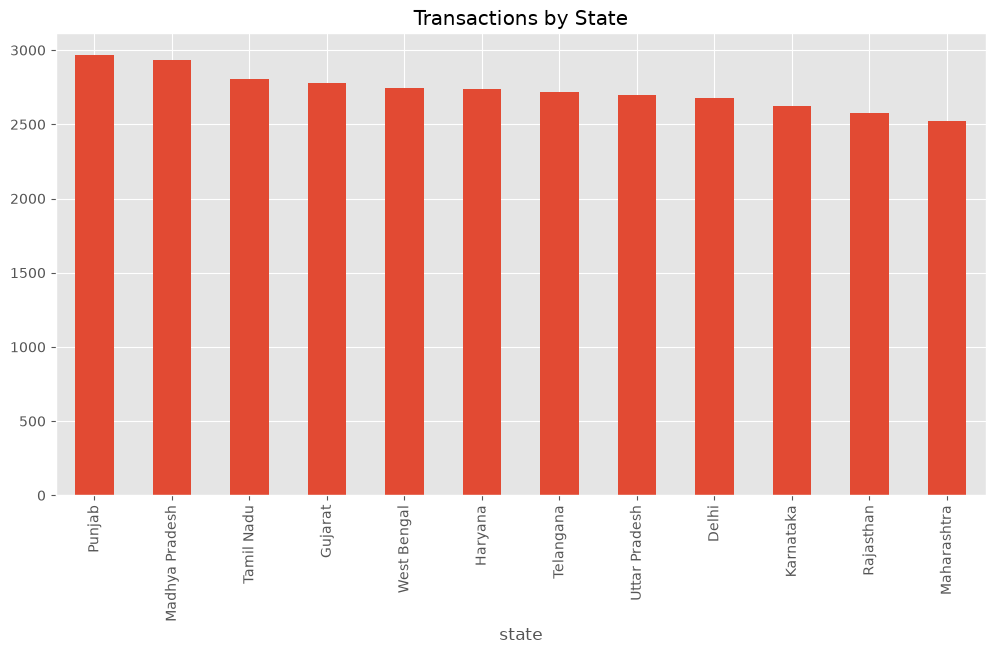

In [22]:
plt.figure(figsize=(12,6))

transaction["state"].value_counts().plot.bar()

plt.title("Transactions by State")
plt.savefig("../reports/charts/07_state_distribution.png", dpi=300)
plt.show()

## Finding 8: Portfolio Sector Allocation

**Observation:**

- Portfolio investments are spread across multiple sectors.
- Some sectors receive significantly larger allocations than others.
- Diversified sector allocation helps reduce portfolio risk.

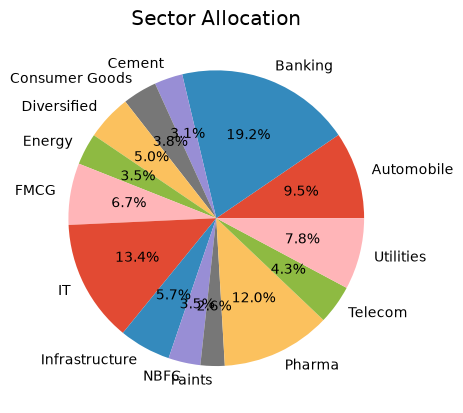

In [23]:
holding.groupby("sector")["weight_pct"].sum().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")
fig.write_image("../reports/charts/08_folio_growth.png")
plt.show()

## Finding 9: Correlation Between Performance Metrics

**Observation:**

- Several financial performance indicators show positive correlation.
- Some variables exhibit weak or negative relationships.
- Correlation analysis helps identify metrics that influence fund performance.

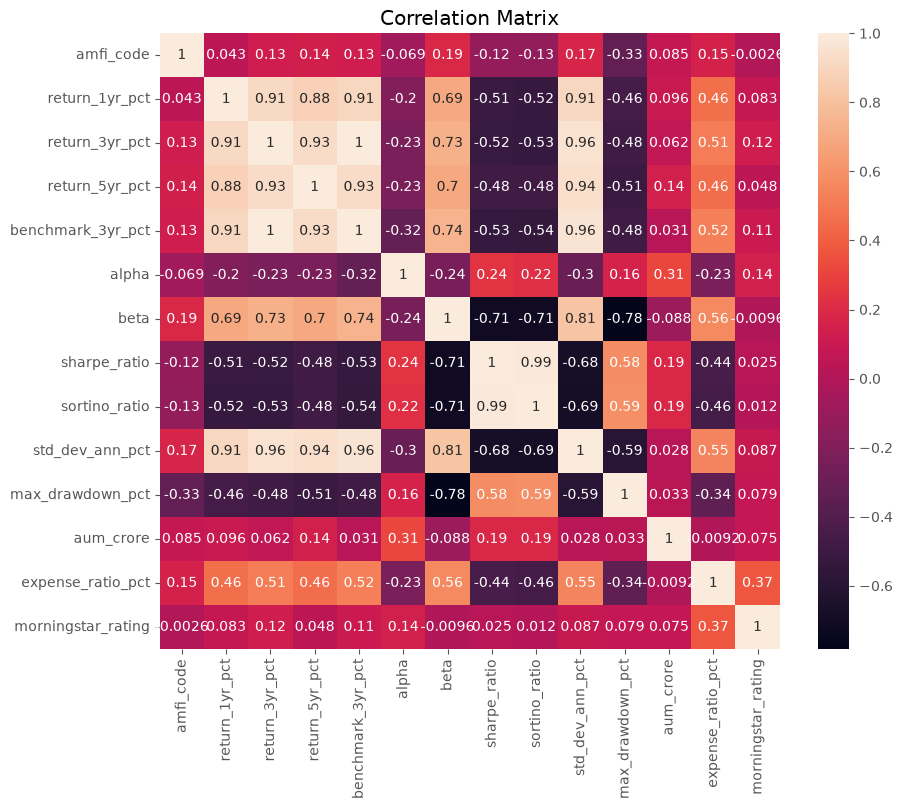

In [24]:
corr = performance.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix")
plt.savefig("../reports/charts/09_correlation_heatmap.png", dpi=300)
plt.show()